# Preprocessing

* Data Exploration

## Describe columns


### Row ID: unique identifier for each record.(No changes were made and kept as is).
### Order ID:unique categorical codes used for tracking orders and customer behaviors.
###  Ship Date: converted to 'datetime' format to calculate shipping duration and analyze sales trends over time.
### Customer Name: standardized text data by removing extra spaces and correcting string format.
### Segment:categorical data grouped to compare revenue generated by different customer type.
### country ,city ,state ,& region: geographical columns used to segment sales by region.
### Postal Code: handled missing values and ensured correct format for accurate spatial mapping.
### Product ID: categorical variables used to identify top selling and low-performing items.
### Category&Sub-Category:grouped to compare profitability across different product line.
### sales :numerical column cleaned of negative outliers to aggregate total revenue per region and category.
### Quantity: integer values checked for negative numbers to ensure valid product volume per order.
### Discount:numerical column analyzed using correlation plots to measure its effect on final profits.
### Profit: key target metric used to identify loss-making categories like tables and highest earners like technology.

* imports the primary python libary required

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

* load dataset

In [56]:
df=pd.read_excel('sample_-_superstore.xls')

* `df.head` gives me the first five rows, and `tail` gives the last five rows.

In [57]:
df.head()
df.tail()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10189,10190,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,2026-12-30,2027-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,2026-12-30,2027-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,2026-12-30,2027-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
10193,10194,CA-2026-143500,2026-12-30,2027-01-03,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,...,C0A,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,3.024,3,0.2,-0.6048


* The shape lets me know the number of rows and columns.

In [58]:
df.shape

(10194, 21)

* **concise summary of data types and non null counts

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

* It gives me the total of the repeated rows.

In [60]:
df.duplicated().sum()

np.int64(0)

* It returns the rows that contain empty values.

In [61]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

statistical summary for numerical  columns

In [62]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


* You are exploring unique values.

In [63]:
df["Category"].unique()

<ArrowStringArray>
['Office Supplies', 'Furniture', 'Technology']
Length: 3, dtype: str

* **Exploring the number of unique values

In [64]:
df["Category"].nunique()

3

* **Exploring the frequency of each value

In [65]:
df["Category"].value_counts()

Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

* **gives a summary of the numerical data and shows the main statistics such as the mean, minimum, maximum.

In [66]:
df["Profit"].describe()

count    10194.000000
mean        28.673417
std        232.465115
min      -6599.978000
25%          1.760800
50%          8.690000
75%         29.297925
max       8399.976000
Name: Profit, dtype: float64

* Data preprocessing&cleaning

* convert postal code to str format

In [67]:
df['Postal Code']= df['Postal Code'].astype(str)

* remove extra spaces and upper case



In [68]:
df["Category"] = df["Category"].str.strip().str.upper()
df["Sub-Category"] = df["Sub-Category"].str.strip().str.upper()
df["Segment"] = df["Segment"].str.strip().str.upper()


*  remove duplicates record

In [69]:
df.drop_duplicates(inplace=True)

* handling missing value

In [70]:
df.dropna(inplace=True)

* cleaned dataset on excel file

In [71]:
df.to_excel("cleaned_superstore.xlsx",index=False)

## EDA


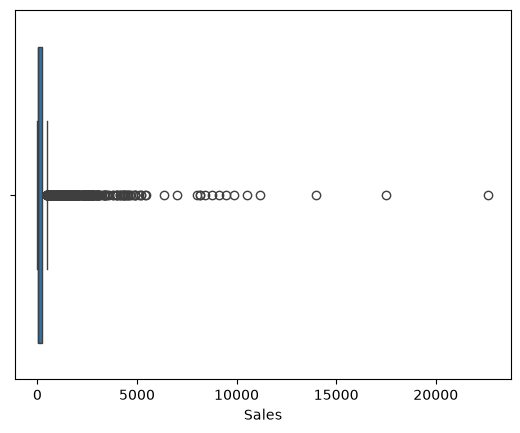

In [72]:
sns.boxplot(x=df["Sales"])
plt.show()

insight= most sales (between 0 and 1000) and outliers >5000

* recommendation=**keep high-value orders to save revenue

In [73]:
outliers = df[(df["Sales"] >5000)]

In [74]:
df.corr(numeric_only=True)

,Row ID,Sales,Quantity,Discount,Profit
Row ID,1.000000,-0.008958,0.000502,-0.001474,0.003022
Sales,-0.008958,1.000000,0.198457,-0.027756,0.481460
Quantity,0.000502,0.198457,1.000000,0.007475,0.066145
Discount,-0.001474,-0.027756,0.007475,1.000000,-0.218882
Profit,0.003022,0.481460,0.066145,-0.218882,1.000000


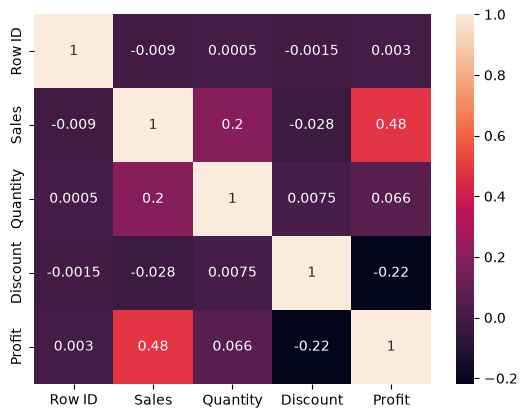

In [75]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

insight=
* sales&profit(0.48) positive correlation
* Discount&profit(-0.22)negative correlation

*  recommendation=**Avoid discounts exceeding 20% ​​to prevent a loss in profit.

insight=Number of repeat sales (between 0 and 100)

* recommendation=Product suggestions at checkout to increase low-value orders.

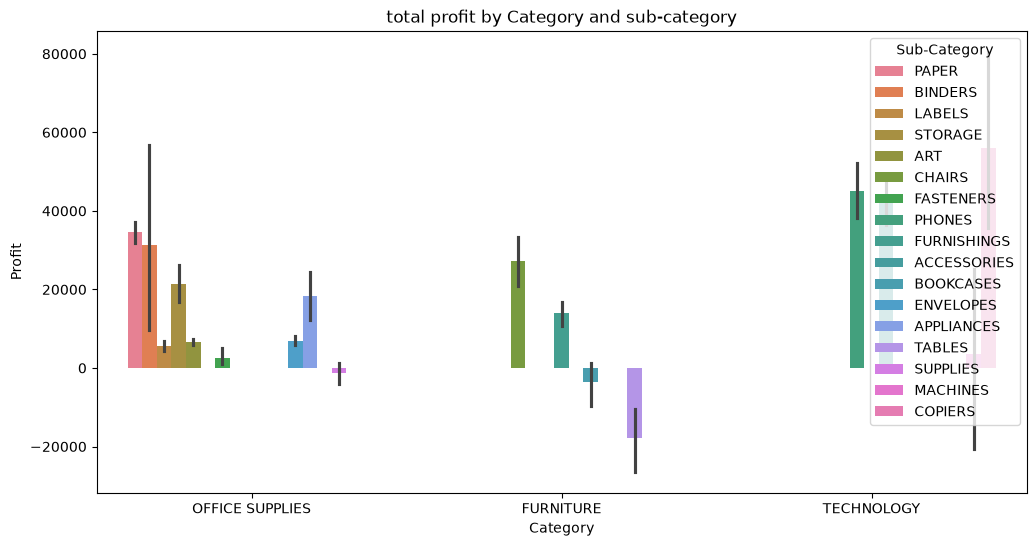

In [77]:
plt.figure(figsize=(12,6))
sns.barplot(x='Category',y='Profit',hue= 'Sub-Category',data=df,estimator=sum)
plt.title('total profit by Category and sub-category')
plt.show()

* insights=The technology division is the most profitable, while the furniture division's profits are very weak.

recommendation=stop heavy discounts on furniure(tables) to prevent losses and push top tech items

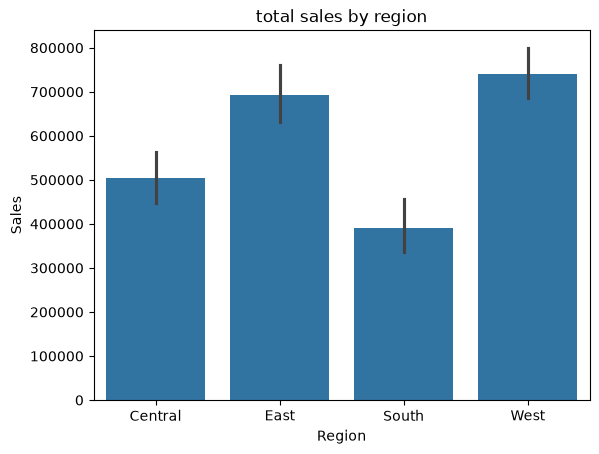

In [78]:
sns.barplot(x='Region',y='Sales',data=df,estimator=sum)
plt.title('total sales by region')
plt.show()

insight=

* Region West is the best-selling
* The south region has the lowest sales.

recommendation =
invest more west&east marketing and revise strategy to boost south sales

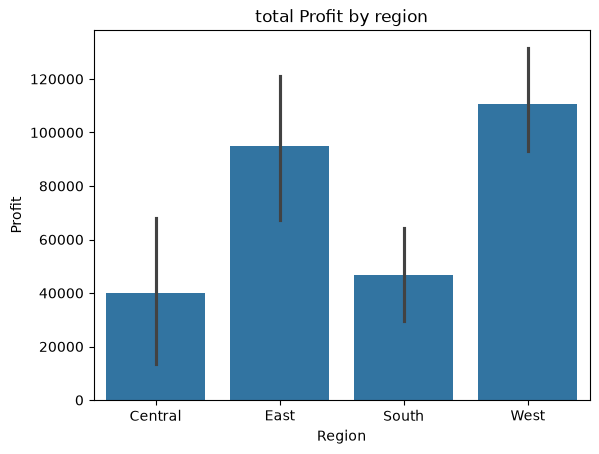

In [79]:
sns.barplot(x='Region',y='Profit',data=df,estimator=sum)
plt.title('total Profit by region')
plt.show()

insight
*  region west Most profitable
*  region central Least profitable

recommendation=**focus operations on west&east sustain high profits and fix margins in central

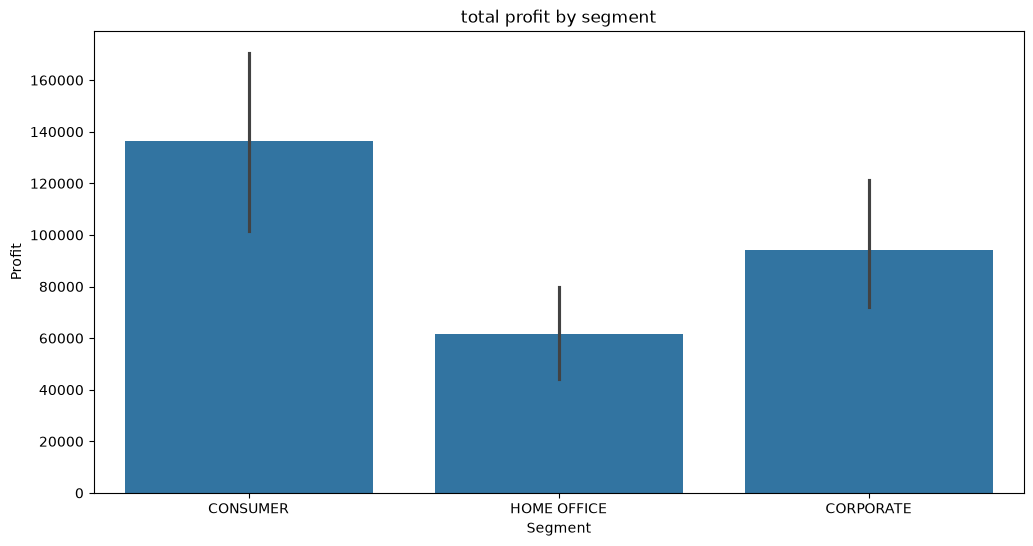

In [80]:
plt.figure(figsize=(12,6))
sns.barplot(x='Segment',y='Profit',data=df,estimator=sum)
plt.title('total profit by segment')
plt.show()

insight=
* consumer segment most profitable

* Home Office segment least profitable

recommendation=
expand marketing for the consumer segment and target bulk corporate offers to grow home office profits

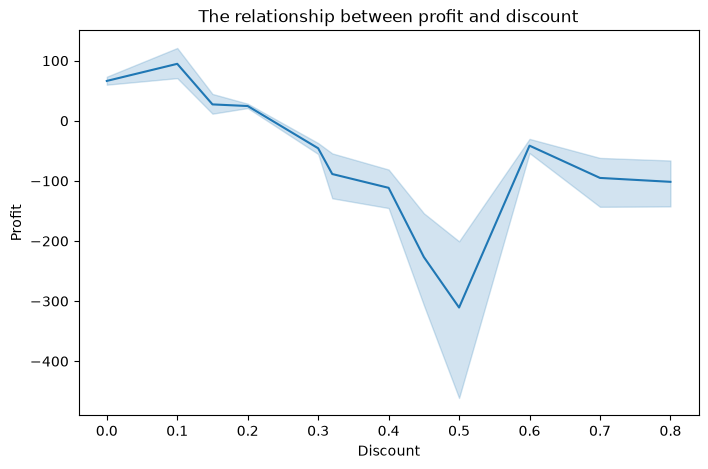

In [81]:
plt.figure(figsize=(8,5))
sns.lineplot(x='Discount',y='Profit',data=df,)
plt.title('The relationship between profit and discount')
plt.show()

insight=

discount above 20% lead financial losses

recommendation= discount maximum of 20% to protect profit

# README

### Finding 1
technology has the highest profit.
### finding 2
tables category has negative profit.
### finding 3
sales increase at the end of the year
### finding 4 
east region achieves the highest sales.
### finding 5
high discount reduce total profit.
### finding 6
consumer segment brings the most revenue.
### finding 7
standard class is the most used shipping method